In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    HybridPoolingV0(30,nn.AvgPool2d,nn.MaxPool2d),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 60, 3, padding=1, groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model43_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model43_0)
describe(model43_0)

MACs: 4.37 MMac, Params: 22.11 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model43_0.pt
Starting
Epoch 1/60: Train loss = 1.1424, Train accuracy = 0.5911, Test loss = 1.1428, Test accuracy = 0.5953
Epoch 2/60: Train loss = 0.9044, Train accuracy = 0.6790, Test loss = 0.8800, Test accuracy = 0.6871
Epoch 3/60: Train loss = 0.8320, Train accuracy = 0.7024, Test loss = 0.8428, Test accuracy = 0.7018
Epoch 4/60: Train loss = 0.7140, Train accuracy = 0.7499, Test loss = 0.7401, Test accuracy = 0.7426
Epoch 5/60: Train loss = 0.7504, Train accuracy = 0.7326, Test loss = 0.7747, Test accuracy = 0.7321
Epoch 6/60: Train loss = 0.7615, Train accuracy = 0.7391, Test loss = 0.7951, Test accuracy = 0.7389
Epoch 7/60: Train loss = 0.7481, Train accuracy = 0.7389, Test loss = 0.8054, Test accuracy = 0.7264
Epoch 8/60: Train loss = 0.6588, Train accuracy = 0.7742, Test loss = 0.7040, Test accuracy = 0.7678
Epoch 9/60: Train loss = 0.5958, Train accuracy = 0.7932, Test loss = 0.6428, Test accuracy = 0.7853
Epoch 10/60: Train loss = 0.652

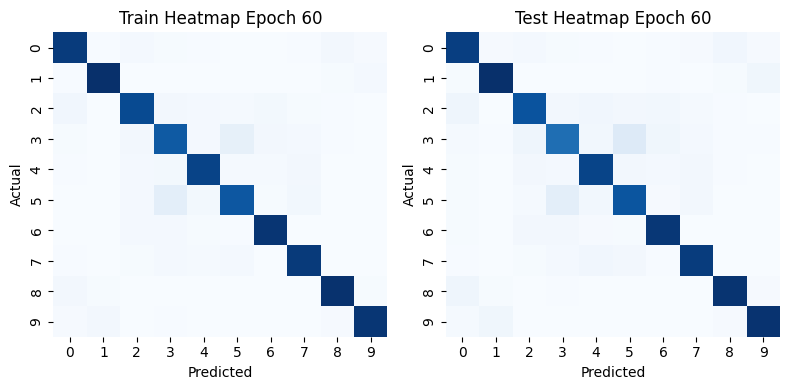

<Figure size 1200x600 with 0 Axes>

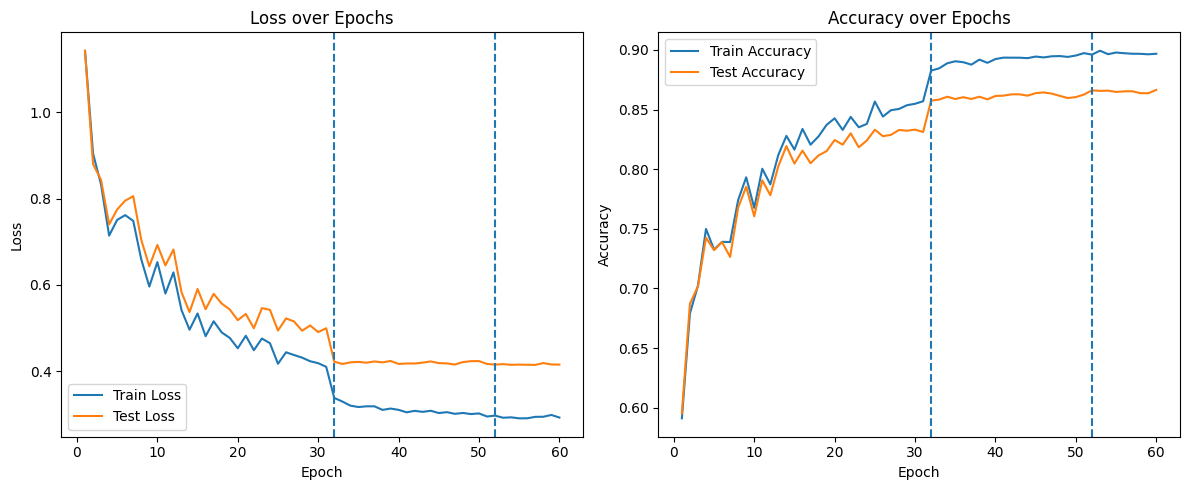

In [6]:
trainf32(model43_0,"model_weights/model43_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model43_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model43_1)
describe(model43_1)

MACs: 4.37 MMac, Params: 22.11 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model43_1.pt
Starting
Epoch 1/60: Train loss = 0.9902, Train accuracy = 0.6510, Test loss = 1.0085, Test accuracy = 0.6427
Epoch 2/60: Train loss = 0.9132, Train accuracy = 0.6889, Test loss = 0.9272, Test accuracy = 0.6906
Epoch 3/60: Train loss = 0.7354, Train accuracy = 0.7444, Test loss = 0.7450, Test accuracy = 0.7443
Epoch 4/60: Train loss = 0.8823, Train accuracy = 0.7058, Test loss = 0.9336, Test accuracy = 0.7012
Epoch 5/60: Train loss = 0.6797, Train accuracy = 0.7648, Test loss = 0.6684, Test accuracy = 0.7697
Epoch 6/60: Train loss = 0.6428, Train accuracy = 0.7759, Test loss = 0.6697, Test accuracy = 0.7695
Epoch 7/60: Train loss = 0.5762, Train accuracy = 0.8026, Test loss = 0.5826, Test accuracy = 0.7969
Epoch 8/60: Train loss = 0.5377, Train accuracy = 0.8120, Test loss = 0.5559, Test accuracy = 0.8072
Epoch 9/60: Train loss = 0.5713, Train accuracy = 0.8010, Test loss = 0.6085, Test accuracy = 0.7910
Epoch 10/60: Train loss = 0.539

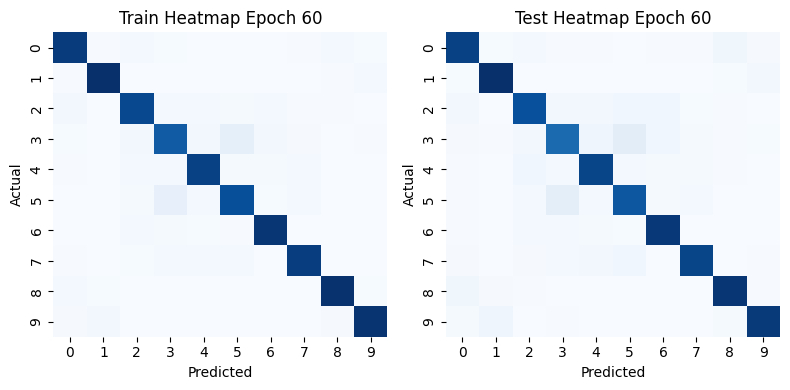

<Figure size 1200x600 with 0 Axes>

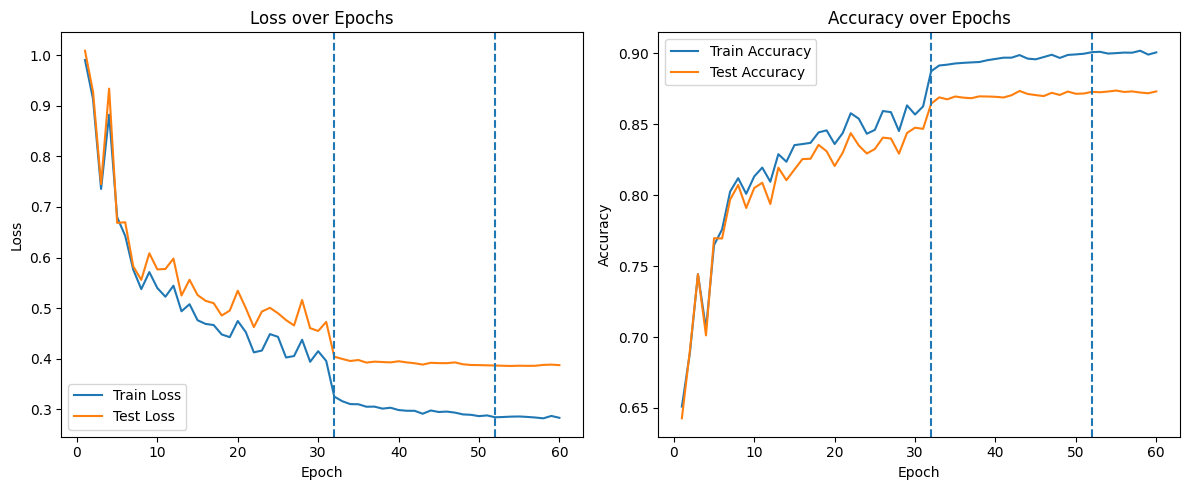

In [8]:
trainf32(model43_1,"model_weights/model43_1.pt",criterion,train_dataset,val_dataset, batch_size=64)